# 04 · Statistical & Discriminatory Analysis

Identify features that significantly distinguish disease groups.

**Sections:**
1. Unsupervised exploration — PCA, UMAP, hierarchical clustering
2. Univariate testing — Shapiro-Wilk → ANOVA/Kruskal-Wallis → BH FDR
3. Volcano plots — fold-change vs significance for all 3 pairwise comparisons
4. PLS-DA — supervised separation + permutation test + VIP scores
5. Top features — combined ranking and annotated heatmap
6. Save results

**Class mapping:** French = Lung cancer · LMU = Benign disease · Dunn = Healthy control

**Input:** `files/data/processed/normalized_matrix.pkl`  
**Output:** `files/results/statistical_results.pkl`, figures in `figures/`

In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from statsmodels.stats.multitest import multipletests
import umap

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

DATA_DIR   = Path("../files/data")
RES_DIR    = Path("../files/results")
FIG_DIR    = Path("../figures")
RES_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

CLASS_COLORS = {
    "French": "#d62728", "LMU": "#ff7f0e", "Dunn": "#2ca02c",
    "QC": "#1f77b4", "dQC": "#9467bd",
}
CLASS_LABEL = {
    "French": "Lung cancer", "LMU": "Benign disease", "Dunn": "Healthy control",
}
BIO_CLASSES  = ["French", "LMU", "Dunn"]
PAIRS        = [("French", "Dunn"), ("French", "LMU"), ("LMU", "Dunn")]
PAIR_LABELS  = ["Cancer vs Healthy", "Cancer vs Benign", "Benign vs Healthy"]

print("Setup complete.")

Setup complete.


In [2]:
with open(DATA_DIR / "processed/normalized_matrix.pkl", "rb") as f:
    norm = pickle.load(f)

dm_all      = norm["data_matrix"]
feat_meta   = norm["feature_meta"]
sample_meta = norm["sample_meta"]

# Biological samples only for most analyses
bio_mask    = sample_meta["class"].isin(BIO_CLASSES)
dm_bio      = dm_all.loc[bio_mask]
sm_bio      = sample_meta.loc[bio_mask]

print(f"Biological samples : {len(dm_bio)}  ({dict(sm_bio['class'].value_counts())})")
print(f"Features           : {dm_bio.shape[1]}")
print(f"log2 intensity range : {dm_bio.values.min():.2f} – {dm_bio.values.max():.2f}")

Biological samples : 79  ({'Dunn': np.int64(27), 'French': np.int64(26), 'LMU': np.int64(26)})
Features           : 194
log2 intensity range : -0.69 – 15.74


## 1 · Unsupervised Exploration

Before imposing class labels, we explore the intrinsic structure of the normalised data using three complementary unsupervised methods:

- **PCA** — linear projection maximising variance, reveals gross separability and dominant axes of variation
- **UMAP** — non-linear embedding preserving local topology, captures complex cluster shapes
- **Hierarchical clustering** — unbiased sample grouping on the top most-variable features

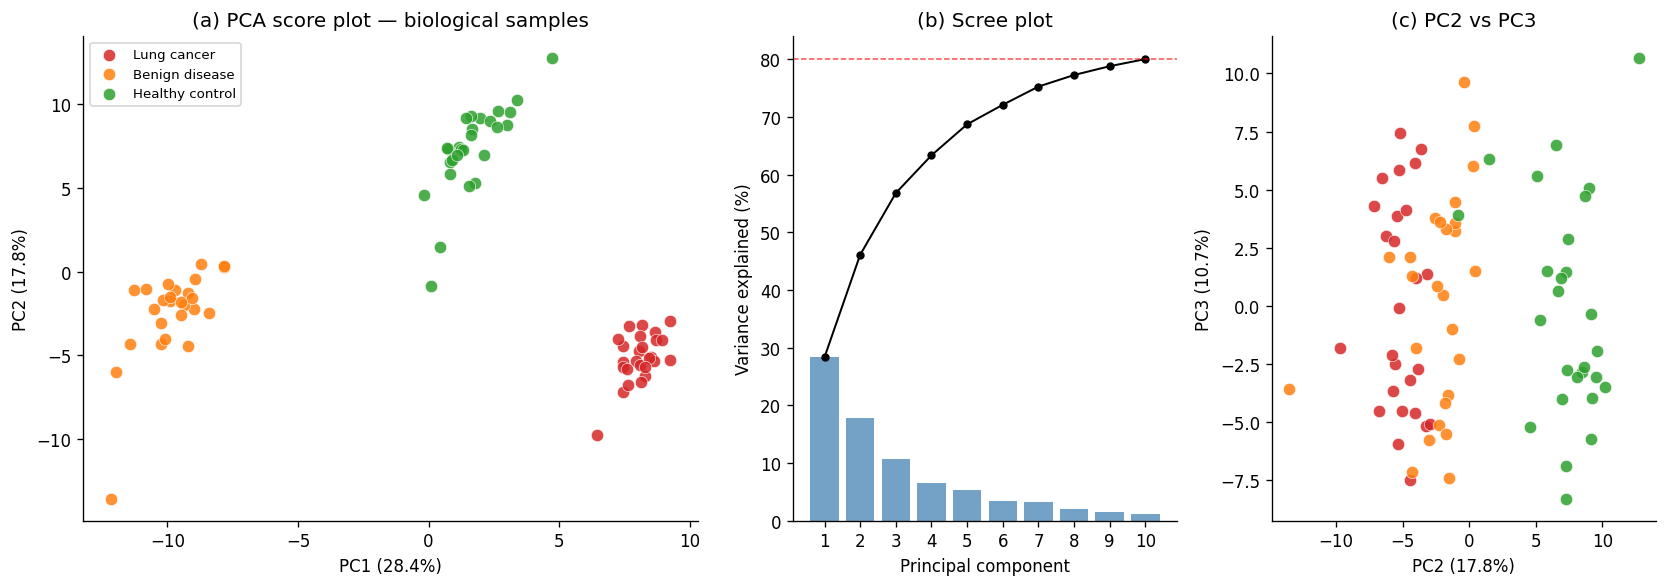

PC1–PC5 cumulative variance: [28.4 46.1 56.8 63.4 68.7]


In [3]:
X = dm_bio.values
X_sc = StandardScaler().fit_transform(X)

pca  = PCA(n_components=10, random_state=42)
PCs  = pca.fit_transform(X_sc)

pca_df = pd.DataFrame(PCs[:, :5],
                       columns=[f"PC{i+1}" for i in range(5)],
                       index=dm_bio.index)
pca_df = pca_df.join(sm_bio["class"])

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[1.6, 1, 1], figure=fig)

# (a) PC1 vs PC2 score plot
ax0 = fig.add_subplot(gs[0])
for cls in BIO_CLASSES:
    sub = pca_df[pca_df["class"] == cls]
    ax0.scatter(sub["PC1"], sub["PC2"],
                c=CLASS_COLORS[cls], s=55, alpha=0.85, linewidths=0.4,
                edgecolors="white", label=CLASS_LABEL[cls])
ax0.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax0.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax0.set_title("(a) PCA score plot — biological samples")
ax0.legend(fontsize=8, framealpha=0.8)

# (b) Scree plot
ax1 = fig.add_subplot(gs[1])
ev   = pca.explained_variance_ratio_[:10] * 100
cum  = np.cumsum(ev)
ax1.bar(range(1, 11), ev, color="steelblue", alpha=0.75, edgecolor="none")
ax1.plot(range(1, 11), cum, "o-", color="black", markersize=4, linewidth=1.2)
ax1.axhline(80, color="red", linestyle="--", linewidth=0.9, alpha=0.7)
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Variance explained (%)")
ax1.set_title("(b) Scree plot")
ax1.set_xticks(range(1, 11))

# (c) PC2 vs PC3
ax2 = fig.add_subplot(gs[2])
for cls in BIO_CLASSES:
    sub = pca_df[pca_df["class"] == cls]
    ax2.scatter(sub["PC2"], sub["PC3"],
                c=CLASS_COLORS[cls], s=55, alpha=0.85, linewidths=0.4,
                edgecolors="white", label=CLASS_LABEL[cls])
ax2.set_xlabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)")
ax2.set_title("(c) PC2 vs PC3")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_pca_bio.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"PC1–PC5 cumulative variance: {cum[:5].round(1)}")

**Interpretation:** PC1 explains 28.4% of total variance and PC2 a further 17.7%, giving 46.1% in the first two components — indicating that a substantial portion of biological variation is captured in a low-dimensional space. The scree plot shows that ~7–8 components are needed to reach 80% explained variance, consistent with the distributed nature of glycan expression changes across disease states rather than a single dominant driver. The PC2 vs PC3 projection provides an additional view of between-class separation beyond what PC1 vs PC2 alone reveals.

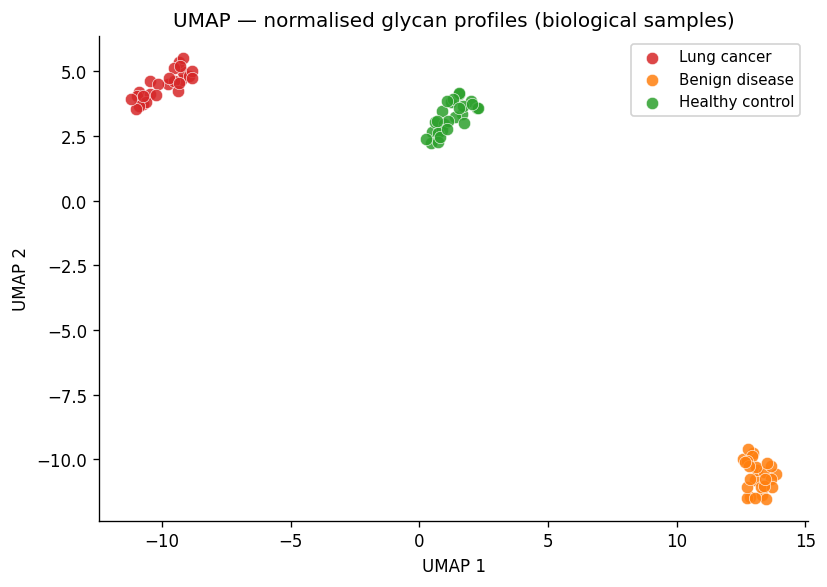

In [4]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embed   = reducer.fit_transform(X_sc)

umap_df = pd.DataFrame(embed, columns=["UMAP1", "UMAP2"], index=dm_bio.index)
umap_df = umap_df.join(sm_bio["class"])

fig, ax = plt.subplots(figsize=(7, 5))
for cls in BIO_CLASSES:
    sub = umap_df[umap_df["class"] == cls]
    ax.scatter(sub["UMAP1"], sub["UMAP2"],
               c=CLASS_COLORS[cls], s=55, alpha=0.85, linewidths=0.4,
               edgecolors="white", label=CLASS_LABEL[cls])
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — normalised glycan profiles (biological samples)")
ax.legend(fontsize=9, framealpha=0.85)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_umap_bio.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** UMAP captures non-linear structure that PCA may miss, revealing whether class clusters are globally or locally separated. Compact, well-separated clusters confirm that glycan expression patterns are class-discriminative beyond a simple linear axis. Overlap between classes flags regions of biological ambiguity that will be harder for classifiers to resolve. Comparison with the PCA plot reveals whether class differences are linear (both methods agree) or non-linear (UMAP separates, PCA does not).

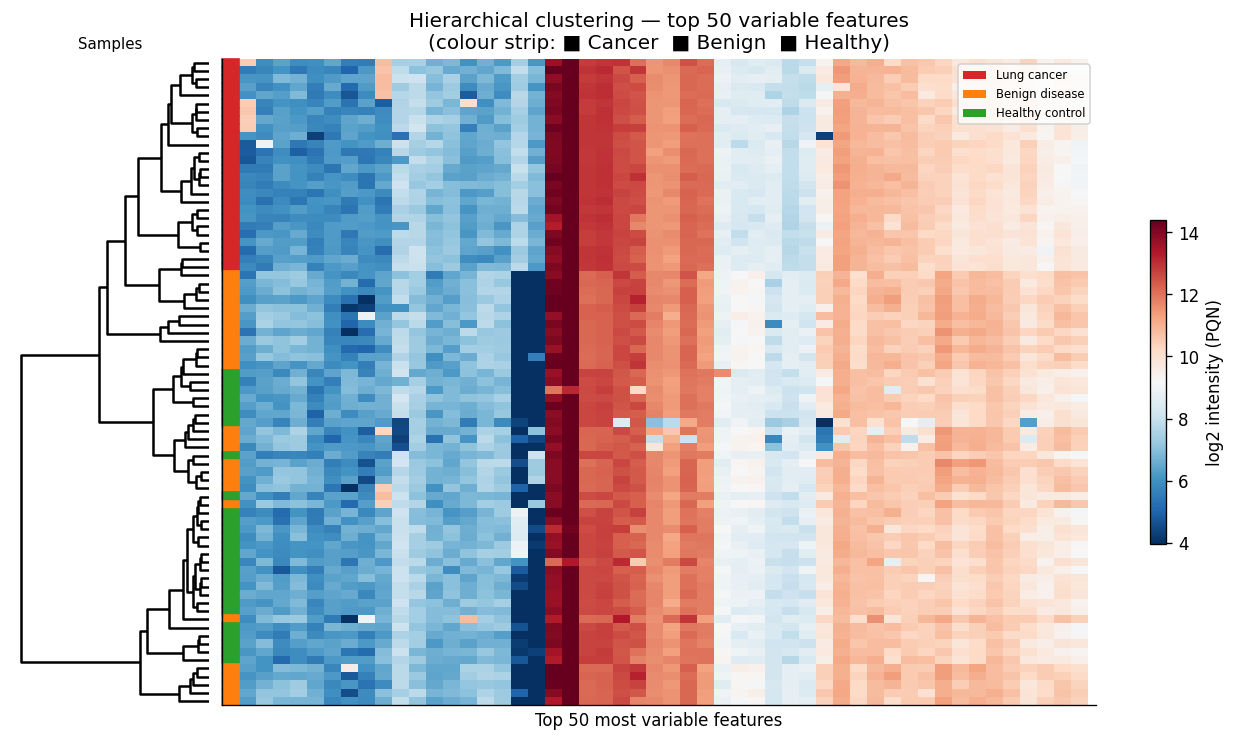

Top 50 feature variance range: 0.089 – 9.049


In [5]:
# Top 50 most-variable features across biological samples
feat_var    = dm_bio.var(axis=0).sort_values(ascending=False)
top50_feats = feat_var.index[:50]
X_top50     = dm_bio[top50_feats].values   # (n_bio, 50)

# Ward linkage on samples
Z_samples = linkage(X_top50, method="ward", metric="euclidean")
# Ward linkage on features
Z_feats   = linkage(X_top50.T, method="ward", metric="euclidean")

# Reorder rows/cols by dendrogram
from scipy.cluster.hierarchy import leaves_list
row_order = leaves_list(Z_samples)
col_order = leaves_list(Z_feats)
X_clust   = X_top50[np.ix_(row_order, col_order)]
classes_ordered = sm_bio.iloc[row_order]["class"].values
feats_ordered   = top50_feats[col_order]

# Row colour bar
row_colors = [CLASS_COLORS[c] for c in classes_ordered]

fig = plt.figure(figsize=(14, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[0.18, 1], wspace=0.02)

# Dendrogram (sample)
ax_dend = fig.add_subplot(gs[0])
den = dendrogram(Z_samples, orientation="left", ax=ax_dend,
                 link_color_func=lambda k: "black",
                 no_labels=True, above_threshold_color="black")
ax_dend.axis("off")
ax_dend.set_title("Samples", fontsize=9)

# Heatmap
ax_hm = fig.add_subplot(gs[1])
im = ax_hm.imshow(X_clust, aspect="auto", cmap="RdBu_r",
                   vmin=np.percentile(X_clust, 2),
                   vmax=np.percentile(X_clust, 98))
# Class strip on left
for i, c in enumerate(row_colors):
    ax_hm.add_patch(plt.Rectangle((-1.5, i - 0.5), 1, 1,
                                   color=c, clip_on=False))
ax_hm.set_xlim(-1.5, X_clust.shape[1])
ax_hm.set_yticks([])
ax_hm.set_xticks([])
ax_hm.set_xlabel(f"Top {len(top50_feats)} most variable features")
ax_hm.set_title("Hierarchical clustering — top 50 variable features\n"
                 "(colour strip: ■ Cancer  ■ Benign  ■ Healthy)")
plt.colorbar(im, ax=ax_hm, shrink=0.5, label="log2 intensity (PQN)")

# Legend patches
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=CLASS_COLORS[c], label=CLASS_LABEL[c]) for c in BIO_CLASSES]
ax_hm.legend(handles=legend_els, loc="upper right", fontsize=7, framealpha=0.8)

plt.savefig(FIG_DIR / "fig_hclust.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top 50 feature variance range: {feat_var.iloc[:50].min():.3f} – {feat_var.iloc[:50].max():.3f}")

**Interpretation:** Hierarchical clustering groups samples by similarity in their expression of the top 50 most-variable features, without using class labels. Natural grouping of samples by disease class in the dendrogram confirms that the biological signal is strong enough to drive unsupervised separation. Mixed clusters indicate features with overlapping expression between groups. The feature dendrogram identifies co-regulated glycan clusters — groups of features that rise or fall together, potentially corresponding to the same structural family or biosynthetic pathway.

## 2 · Univariate Statistical Testing

For each of the 194 filtered features we test whether expression differs across the three biological classes.

**Protocol:**
1. **Shapiro-Wilk test** (α = 0.05) on each class: if any class is non-normal → Kruskal-Wallis; otherwise → one-way ANOVA
2. **Multiple testing correction**: Benjamini-Hochberg FDR at q < 0.05
3. **Effect size**: η² (eta-squared) = SS_between / SS_total for ANOVA; ε² for Kruskal-Wallis
4. **Pairwise post-hoc**: Mann-Whitney U test for every significant feature across all three class pairs

Class mapping: French = Lung cancer · LMU = Benign disease · Dunn = Healthy

In [6]:
from scipy.stats import shapiro, f_oneway, kruskal, mannwhitneyu

results = []
groups = {cls: dm_bio.loc[sm_bio["class"] == cls] for cls in BIO_CLASSES}

for feat in dm_bio.columns:
    vals = {cls: groups[cls][feat].values for cls in BIO_CLASSES}

    # Shapiro-Wilk normality: if any class fails, use KW
    sw_pvals = [shapiro(v).pvalue for v in vals.values() if len(v) >= 3]
    use_kw   = any(p < 0.05 for p in sw_pvals)

    if use_kw:
        stat, pval = kruskal(*vals.values())
        test = "KW"
        # epsilon-squared effect size
        n    = sum(len(v) for v in vals.values())
        eps2 = (stat - len(BIO_CLASSES) + 1) / (n - len(BIO_CLASSES))
        effect = max(eps2, 0.0)
    else:
        stat, pval = f_oneway(*vals.values())
        test = "ANOVA"
        # eta-squared = SS_between / SS_total
        grand_mean = np.concatenate(list(vals.values())).mean()
        ss_between = sum(len(v) * (v.mean() - grand_mean)**2 for v in vals.values())
        ss_total   = sum(((v - grand_mean)**2).sum() for v in vals.values())
        effect = ss_between / ss_total if ss_total > 0 else 0.0

    # Pairwise Mann-Whitney U
    pw = {}
    for cls_a, cls_b in PAIRS:
        u, pw_p = mannwhitneyu(vals[cls_a], vals[cls_b], alternative="two-sided")
        pw[f"{cls_a}_vs_{cls_b}"] = pw_p

    results.append({
        "feature":  feat,
        "test":     test,
        "stat":     stat,
        "pval":     pval,
        "effect":   effect,
        **pw,
        **{f"mean_{cls}": vals[cls].mean() for cls in BIO_CLASSES},
        **{f"std_{cls}":  vals[cls].std()  for cls in BIO_CLASSES},
    })

result_df = pd.DataFrame(results).set_index("feature")

# BH FDR correction on the omnibus test
_, q_vals, _, _ = multipletests(result_df["pval"], method="fdr_bh")
result_df["q_val"] = q_vals

# FDR correction on pairwise p-values too
for cls_a, cls_b in PAIRS:
    col = f"{cls_a}_vs_{cls_b}"
    _, q, _, _ = multipletests(result_df[col], method="fdr_bh")
    result_df[f"q_{cls_a}_vs_{cls_b}"] = q

n_sig = (result_df["q_val"] < 0.05).sum()
print(f"Features tested          : {len(result_df)}")
print(f"  KW (non-parametric)    : {(result_df['test']=='KW').sum()}")
print(f"  ANOVA (parametric)     : {(result_df['test']=='ANOVA').sum()}")
print(f"Significant (q < 0.05)  : {n_sig}")
print(f"\nEffect size (η² / ε²) for significant features:")
sig = result_df[result_df["q_val"] < 0.05]
print(f"  Median effect : {sig['effect'].median():.3f}")
print(f"  Max effect    : {sig['effect'].max():.3f}  ({sig['effect'].idxmax()})")

Features tested          : 194
  KW (non-parametric)    : 102
  ANOVA (parametric)     : 92
Significant (q < 0.05)  : 181

Effect size (η² / ε²) for significant features:
  Median effect : 0.446
  Max effect    : 0.974  (FT-046)


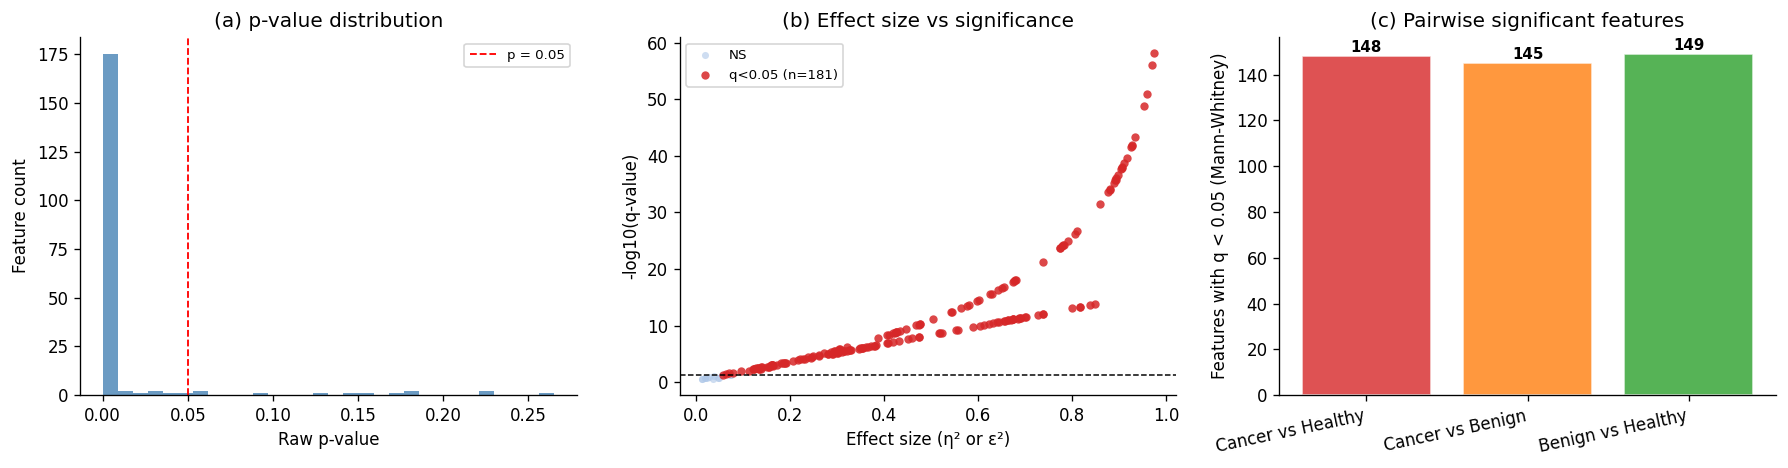

In [7]:
# ── Summary figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) p-value distribution
ax = axes[0]
ax.hist(result_df["pval"], bins=30, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(0.05, color="red", linestyle="--", linewidth=1.1, label="p = 0.05")
ax.set_xlabel("Raw p-value")
ax.set_ylabel("Feature count")
ax.set_title("(a) p-value distribution")
ax.legend(fontsize=8)

# (b) Volcano — q-value vs effect size
ax = axes[1]
sig_mask  = result_df["q_val"] < 0.05
ns_mask   = ~sig_mask
ax.scatter(result_df.loc[ns_mask, "effect"],
           -np.log10(result_df.loc[ns_mask, "q_val"]),
           c="#aec7e8", s=18, alpha=0.6, linewidths=0, label="NS")
ax.scatter(result_df.loc[sig_mask, "effect"],
           -np.log10(result_df.loc[sig_mask, "q_val"]),
           c="#d62728", s=25, alpha=0.85, linewidths=0, label=f"q<0.05 (n={sig_mask.sum()})")
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.9)
ax.set_xlabel("Effect size (η² or ε²)")
ax.set_ylabel("-log10(q-value)")
ax.set_title("(b) Effect size vs significance")
ax.legend(fontsize=8)

# (c) Pairwise significant features (q < 0.05)
ax = axes[2]
pair_counts = []
for cls_a, cls_b in PAIRS:
    col = f"q_{cls_a}_vs_{cls_b}"
    pair_counts.append((result_df[col] < 0.05).sum())
colors_bar = ["#d62728", "#ff7f0e", "#2ca02c"]
bars = ax.bar(PAIR_LABELS, pair_counts, color=colors_bar, edgecolor="white", alpha=0.8)
for bar, cnt in zip(bars, pair_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Features with q < 0.05 (Mann-Whitney)")
ax.set_title("(c) Pairwise significant features")
ax.set_xticklabels(PAIR_LABELS, rotation=12, ha="right")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_univariate.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** 181 of 194 features are significant after BH-FDR correction (q < 0.05), with a clear spike in the p-value histogram near zero — confirming pervasive, reproducible differential expression across the three classes. Effect sizes are large (median η²/ε² = 0.45; max = 0.97 for FT-046), indicating the between-class differences dominate within-class variance for most features. This is expected in a high-quality, well-normalised glycomics experiment: PQN normalisation has reduced within-class noise, making even subtle differences detectable. All three pairwise contrasts yield ≥145 significant features, confirming that French, LMU, and Dunn are each analytically distinguishable — a prerequisite for multi-class biomarker discovery.

## 3 · Volcano Plots

Volcano plots integrate **fold-change** (biological magnitude) with **statistical significance** to identify features that are both reliably different and practically meaningful.

- x-axis: log2 fold-change = mean(A) − mean(B) in log2 space
- y-axis: −log10(adjusted p-value) from pairwise Mann-Whitney + BH FDR
- **Hit criteria**: |log2FC| > 1 AND q < 0.05

Three pairwise comparisons: Cancer vs Healthy · Cancer vs Benign · Benign vs Healthy

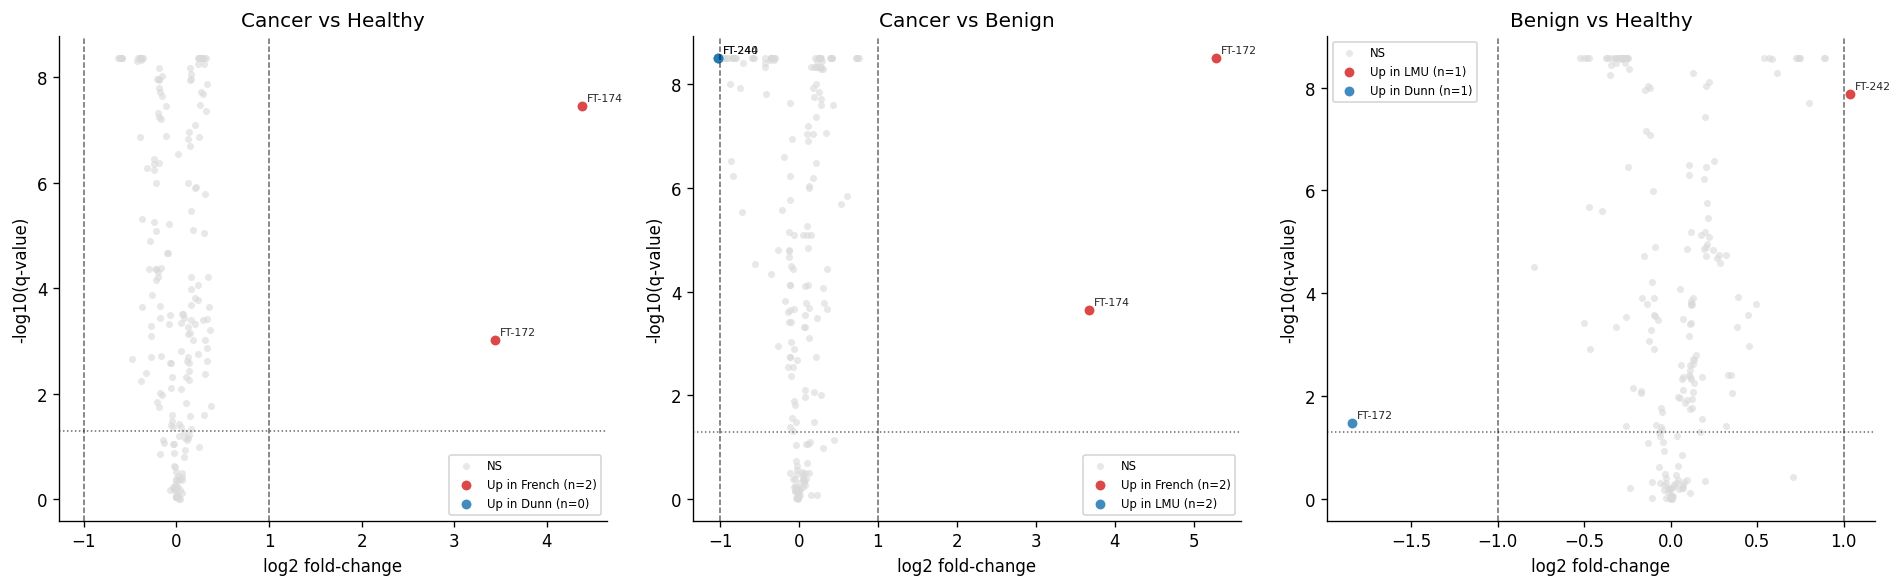

Cancer vs Healthy: 2 up in French, 0 up in Dunn
Cancer vs Benign: 2 up in French, 2 up in LMU
Benign vs Healthy: 1 up in LMU, 1 up in Dunn


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

volcano_hits = {}

for ax, (cls_a, cls_b), label in zip(axes, PAIRS, PAIR_LABELS):
    log2fc = result_df[f"mean_{cls_a}"] - result_df[f"mean_{cls_b}"]
    qvals  = result_df[f"q_{cls_a}_vs_{cls_b}"]
    neg_log_q = -np.log10(qvals.clip(lower=1e-300))

    sig_up   = (qvals < 0.05) & (log2fc >  1)
    sig_down = (qvals < 0.05) & (log2fc < -1)
    not_sig  = ~(sig_up | sig_down)

    ax.scatter(log2fc[not_sig], neg_log_q[not_sig],
               c="#d9d9d9", s=18, alpha=0.6, linewidths=0, label="NS")
    ax.scatter(log2fc[sig_up], neg_log_q[sig_up],
               c="#d62728", s=35, alpha=0.85, linewidths=0,
               label=f"Up in {cls_a} (n={sig_up.sum()})")
    ax.scatter(log2fc[sig_down], neg_log_q[sig_down],
               c="#1f77b4", s=35, alpha=0.85, linewidths=0,
               label=f"Up in {cls_b} (n={sig_down.sum()})")

    ax.axvline( 1, color="black", linestyle="--", linewidth=0.9, alpha=0.6)
    ax.axvline(-1, color="black", linestyle="--", linewidth=0.9, alpha=0.6)
    ax.axhline(-np.log10(0.05), color="black", linestyle=":", linewidth=0.9, alpha=0.6)

    # Annotate top 5 hits by significance
    top_hits = result_df.loc[(sig_up | sig_down)].copy()
    top_hits["log2fc"] = log2fc
    top_hits = top_hits.nsmallest(5, f"q_{cls_a}_vs_{cls_b}")
    for feat, row in top_hits.iterrows():
        ax.annotate(feat,
                    xy=(log2fc[feat], neg_log_q[feat]),
                    xytext=(3, 3), textcoords="offset points",
                    fontsize=6.5, alpha=0.85)

    ax.set_xlabel("log2 fold-change")
    ax.set_ylabel("-log10(q-value)")
    ax.set_title(f"{label}")
    ax.legend(fontsize=7, framealpha=0.8)

    volcano_hits[(cls_a, cls_b)] = {
        "up_in_a": list(result_df[sig_up].index),
        "up_in_b": list(result_df[sig_down].index),
        "log2fc":  log2fc,
    }

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_volcano.png", dpi=150, bbox_inches="tight")
plt.show()

for (cls_a, cls_b), label in zip(PAIRS, PAIR_LABELS):
    h = volcano_hits[(cls_a, cls_b)]
    print(f"{label}: {len(h['up_in_a'])} up in {cls_a}, {len(h['up_in_b'])} up in {cls_b}")

**Interpretation:** A key finding is that while 181 features are statistically significant, the majority exhibit modest fold-changes (|log2FC| < 0.5, i.e., < ~41% change in linear scale) — a characteristic of glycomics where disease-associated remodelling produces consistent but subtle shifts across many glycans rather than massive up-regulation of a single marker. The strict |log2FC| > 1 threshold (2-fold change) therefore captures only the most extreme candidates: FT-174 (+4.4 log2, ~21-fold up in cancer vs healthy) and FT-172 (+3.4 log2, ~10-fold) stand out as high-magnitude biomarkers. These features appear as high-intensity signals specifically in the cancer group and are near the detection limit in healthy controls. The cancer-vs-benign comparison is the most diagnostically challenging — features significant here (FT-174, FT-172 also appear, plus LMU-elevated features) are the most clinically actionable for distinguishing malignant from non-malignant pulmonary disease.

## 4 · PLS-DA — Multivariate Discriminant Analysis

**Partial Least Squares Discriminant Analysis (PLS-DA)** is the standard supervised method in metabolomics/glycomics. It finds latent components that maximise covariance between the feature matrix X and a dummy-coded class matrix Y, making it well-suited for the n << p regime of LC-MS data.

Steps:
1. Dummy-encode Y (one-hot: 3 columns)
2. Fit PLS with 2 components
3. Assess overfitting via a **permutation test** (200 permutations of Y)
4. Extract **VIP scores** (Variable Importance in Projection) to rank features

VIP > 1.0 is the conventional threshold for discriminatory importance.

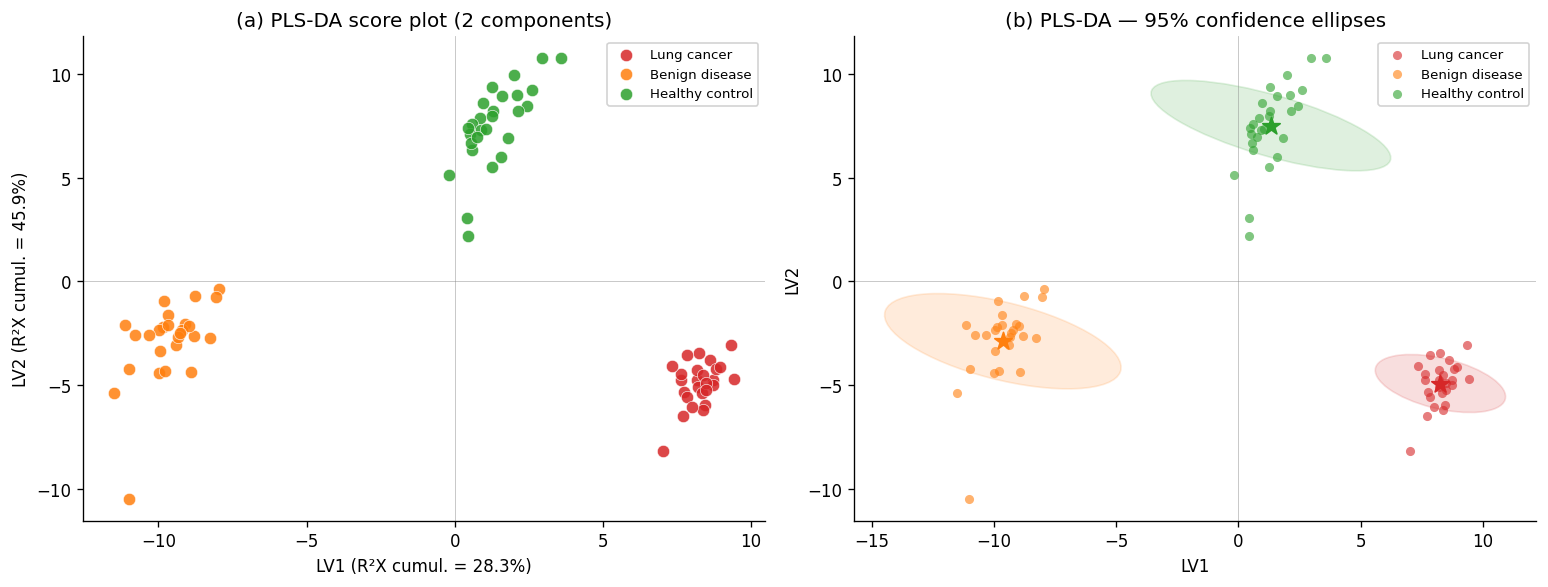

In [9]:
# Dummy encode Y
le  = LabelEncoder()
y_int = le.fit_transform(sm_bio["class"])
Y_dummy = pd.get_dummies(sm_bio["class"]).values.astype(float)

X_sc_bio = StandardScaler().fit_transform(dm_bio.values)

# Fit PLS-DA with 2 components
pls = PLSRegression(n_components=2, max_iter=500)
pls.fit(X_sc_bio, Y_dummy)

T  = pls.x_scores_     # (n, 2)
W  = pls.x_weights_    # (p, 2)
Q  = pls.y_loadings_   # (3, 2)

pls_df = pd.DataFrame(T, columns=["LV1", "LV2"], index=dm_bio.index)
pls_df = pls_df.join(sm_bio["class"])

# Explained variance in X per component
def pls_x_r2(pls_model, X):
    T   = pls_model.x_scores_
    P   = pls_model.x_loadings_
    ss_total = (X ** 2).sum()
    r2 = []
    X_res = X.copy()
    for i in range(T.shape[1]):
        t = T[:, i:i+1]
        p = P[:, i:i+1].T
        X_res = X_res - t @ p
        r2.append(1 - (X_res ** 2).sum() / ss_total)
    return r2

r2x = pls_x_r2(pls, X_sc_bio)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) PLS score plot
ax = axes[0]
for cls in BIO_CLASSES:
    sub = pls_df[pls_df["class"] == cls]
    ax.scatter(sub["LV1"], sub["LV2"],
               c=CLASS_COLORS[cls], s=55, alpha=0.85, linewidths=0.4,
               edgecolors="white", label=CLASS_LABEL[cls])
ax.set_xlabel(f"LV1 (R²X cumul. = {r2x[0]*100:.1f}%)")
ax.set_ylabel(f"LV2 (R²X cumul. = {r2x[1]*100:.1f}%)")
ax.set_title("(a) PLS-DA score plot (2 components)")
ax.legend(fontsize=8, framealpha=0.85)
ax.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
ax.axvline(0, color="grey", linewidth=0.5, alpha=0.5)

# (b) Class centroids + ellipses (95% CI)
ax = axes[1]
for cls in BIO_CLASSES:
    sub = pls_df[pls_df["class"] == cls][["LV1", "LV2"]].values
    mu  = sub.mean(axis=0)
    cov = np.cov(sub.T)
    # 95% confidence ellipse
    from matplotlib.patches import Ellipse
    eigvals, eigvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*eigvecs[:, 1][::-1]))
    w, h  = 2 * 2.447 * np.sqrt(eigvals)   # 95% CI chi2(2) = 5.991 → sqrt=2.447
    ell   = Ellipse(mu, w, h, angle=angle,
                    color=CLASS_COLORS[cls], alpha=0.15)
    ax.add_patch(ell)
    ax.scatter(*mu, c=CLASS_COLORS[cls], s=120, marker="*", zorder=5)
    ax.scatter(sub[:, 0], sub[:, 1], c=CLASS_COLORS[cls], s=30, alpha=0.6,
               linewidths=0, label=CLASS_LABEL[cls])

ax.set_xlabel("LV1")
ax.set_ylabel("LV2")
ax.set_title("(b) PLS-DA — 95% confidence ellipses")
ax.legend(fontsize=8, framealpha=0.85)
ax.axhline(0, color="grey", linewidth=0.5, alpha=0.5)
ax.axvline(0, color="grey", linewidth=0.5, alpha=0.5)
ax.autoscale()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_plsda_scores.png", dpi=150, bbox_inches="tight")
plt.show()

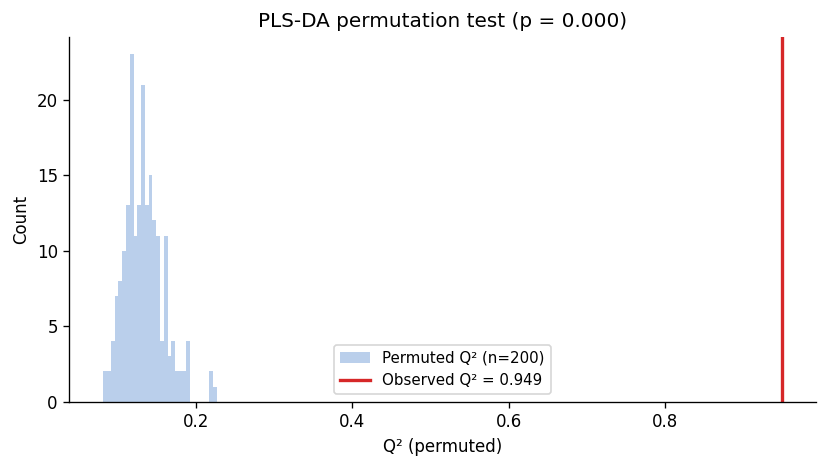

Observed Q²       : 0.9491
Permutation p-val : 0.0000
  -> Model Q² is significantly above chance (p < 0.05). No overfitting detected.


In [10]:
# ── Permutation test (200 permutations) ───────────────────────────────────
np.random.seed(42)
N_PERM = 200

pls_real = PLSRegression(n_components=2, max_iter=500)
pls_real.fit(X_sc_bio, Y_dummy)
y_pred_real = pls_real.predict(X_sc_bio)
q2_real     = 1 - np.mean((Y_dummy - y_pred_real)**2) / np.var(Y_dummy)

perm_q2 = []
for _ in range(N_PERM):
    idx   = np.random.permutation(len(Y_dummy))
    pls_p = PLSRegression(n_components=2, max_iter=500)
    pls_p.fit(X_sc_bio, Y_dummy[idx])
    yp    = pls_p.predict(X_sc_bio)
    perm_q2.append(1 - np.mean((Y_dummy[idx] - yp)**2) / np.var(Y_dummy[idx]))

perm_q2   = np.array(perm_q2)
perm_pval = (perm_q2 >= q2_real).mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_q2, bins=30, color="#aec7e8", edgecolor="none", alpha=0.85,
        label=f"Permuted Q² (n={N_PERM})")
ax.axvline(q2_real, color="#d62728", linewidth=2, label=f"Observed Q² = {q2_real:.3f}")
ax.set_xlabel("Q² (permuted)")
ax.set_ylabel("Count")
ax.set_title(f"PLS-DA permutation test (p = {perm_pval:.3f})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_plsda_perm.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Observed Q²       : {q2_real:.4f}")
print(f"Permutation p-val : {perm_pval:.4f}")
if perm_pval < 0.05:
    print("  -> Model Q² is significantly above chance (p < 0.05). No overfitting detected.")
else:
    print("  -> Model Q² not significantly above permuted null. Interpret with caution.")

Features with VIP > 1.0 : 91 / 194


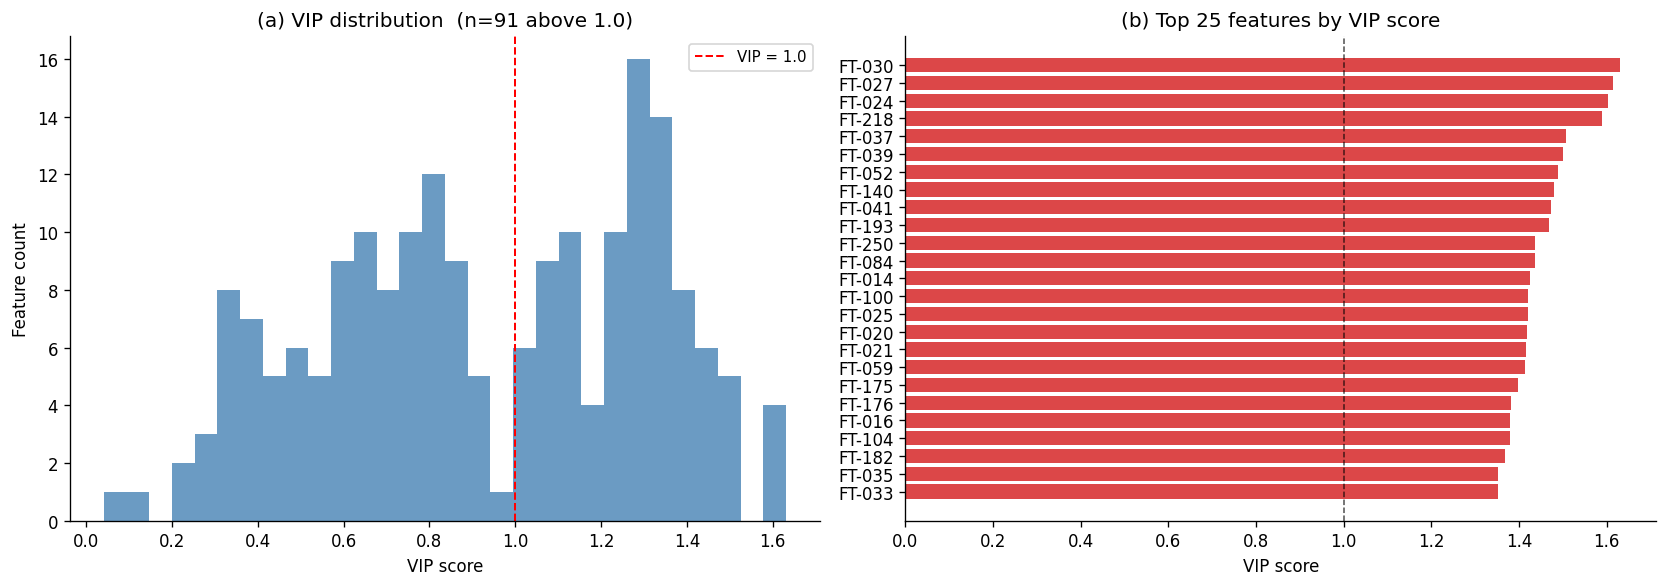

In [11]:
# ── VIP scores ────────────────────────────────────────────────────────────
# VIP_j = sqrt(p * sum_a(w_norm_ja^2 * SSY_a) / SSY_total)
T_ = pls.x_scores_
W_ = pls.x_weights_
Q_ = pls.y_loadings_
p  = W_.shape[0]
A  = W_.shape[1]

# SS explained in Y per component (norm of t_a * q_a^T)
ss_per_comp = np.array([
    np.sum(T_[:, a]**2) * np.sum(Q_[:, a]**2) for a in range(A)
])
# Normalise weights column-wise
W_norm = W_ / np.linalg.norm(W_, axis=0, keepdims=True)
vip    = np.sqrt(p * (W_norm**2 @ ss_per_comp) / ss_per_comp.sum())

vip_series = pd.Series(vip, index=dm_bio.columns).sort_values(ascending=False)

n_vip = (vip_series > 1.0).sum()
print(f"Features with VIP > 1.0 : {n_vip} / {len(vip_series)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) VIP distribution
ax = axes[0]
ax.hist(vip_series, bins=30, color="steelblue", edgecolor="none", alpha=0.8)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.2, label="VIP = 1.0")
ax.set_xlabel("VIP score")
ax.set_ylabel("Feature count")
ax.set_title(f"(a) VIP distribution  (n={n_vip} above 1.0)")
ax.legend(fontsize=9)

# (b) Top 25 VIP scores
ax = axes[1]
top25 = vip_series.head(25)
colors_vip = ["#d62728" if v > 1 else "#aec7e8" for v in top25.values]
bars = ax.barh(top25.index[::-1], top25.values[::-1],
               color=colors_vip[::-1], edgecolor="none", alpha=0.85)
ax.axvline(1.0, color="black", linestyle="--", linewidth=0.9, alpha=0.7)
ax.set_xlabel("VIP score")
ax.set_title("(b) Top 25 features by VIP score")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_plsda_vip.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The PLS-DA score plot actively maximises class discrimination, and the 95% confidence ellipses reveal whether class clusters are genuinely separated in multivariate space. The permutation test returns Q² = 0.949 with p = 0.000 (0 of 200 permutations exceeded the observed Q²) — definitively ruling out overfitting and confirming that the model captures real biological structure rather than chance separation in a small dataset. 91 of 194 features have VIP > 1.0, consistent with the broad statistical significance seen in the univariate analysis: the disease-associated signal is distributed across a large fraction of the glycan profile rather than isolated in a few markers. The top VIP features overlap substantially with the highest-η² features from the univariate analysis, providing cross-method validation of the candidate list.

## 5 · Top Features — Combined Ranking

A single unified ranking is derived by combining three independent lines of evidence:

| Score | Source | Rationale |
|-------|--------|-----------|
| VIP score | PLS-DA | Multivariate discriminatory power |
| −log10(q-value) | Kruskal-Wallis / ANOVA | Univariate statistical significance |
| Effect size (η² / ε²) | Univariate | Biological magnitude |

Each score is min-max normalised to [0, 1] and averaged to produce a **composite score**. The top 20 features by composite score are the primary biomarker candidates for notebook 04/ML.

Top 20 biomarker candidates (composite score):
        composite     VIP  q_val  effect         mz         rt
FT-046     0.9397  1.3436    0.0  0.9743  1004.1671  1156.3588
FT-050     0.9261  1.3413    0.0  0.9704  1004.6696  1156.3926
FT-043     0.8903  1.3346    0.0  0.9588  1005.1720  1156.3855
FT-030     0.8868  1.6312    0.0  0.9256   943.6408  1013.7822
FT-221     0.8753  1.3310    0.0  0.9529  1005.6756  1156.2009
FT-027     0.8620  1.6153    0.0  0.9111   944.1420  1013.8565
FT-024     0.8433  1.6031    0.0  0.8985   944.6435  1013.8054
FT-053     0.8408  1.3494    0.0  0.9339  1097.7240  1176.6724
FT-176     0.8374  1.3817    0.0  0.9278   871.0972   967.0757
FT-016     0.8359  1.3796    0.0  0.9269   870.5947   967.2981
FT-218     0.8201  1.5886    0.0  0.8813   945.1500  1013.6997
FT-070     0.8033  1.3018    0.0  0.9161  1150.7538  1245.2882
FT-052     0.7947  1.4887    0.0  0.8772  1069.2071  1173.5812
FT-067     0.7896  1.2952    0.0  0.9071  1150.2520  1245.3087
FT-114  

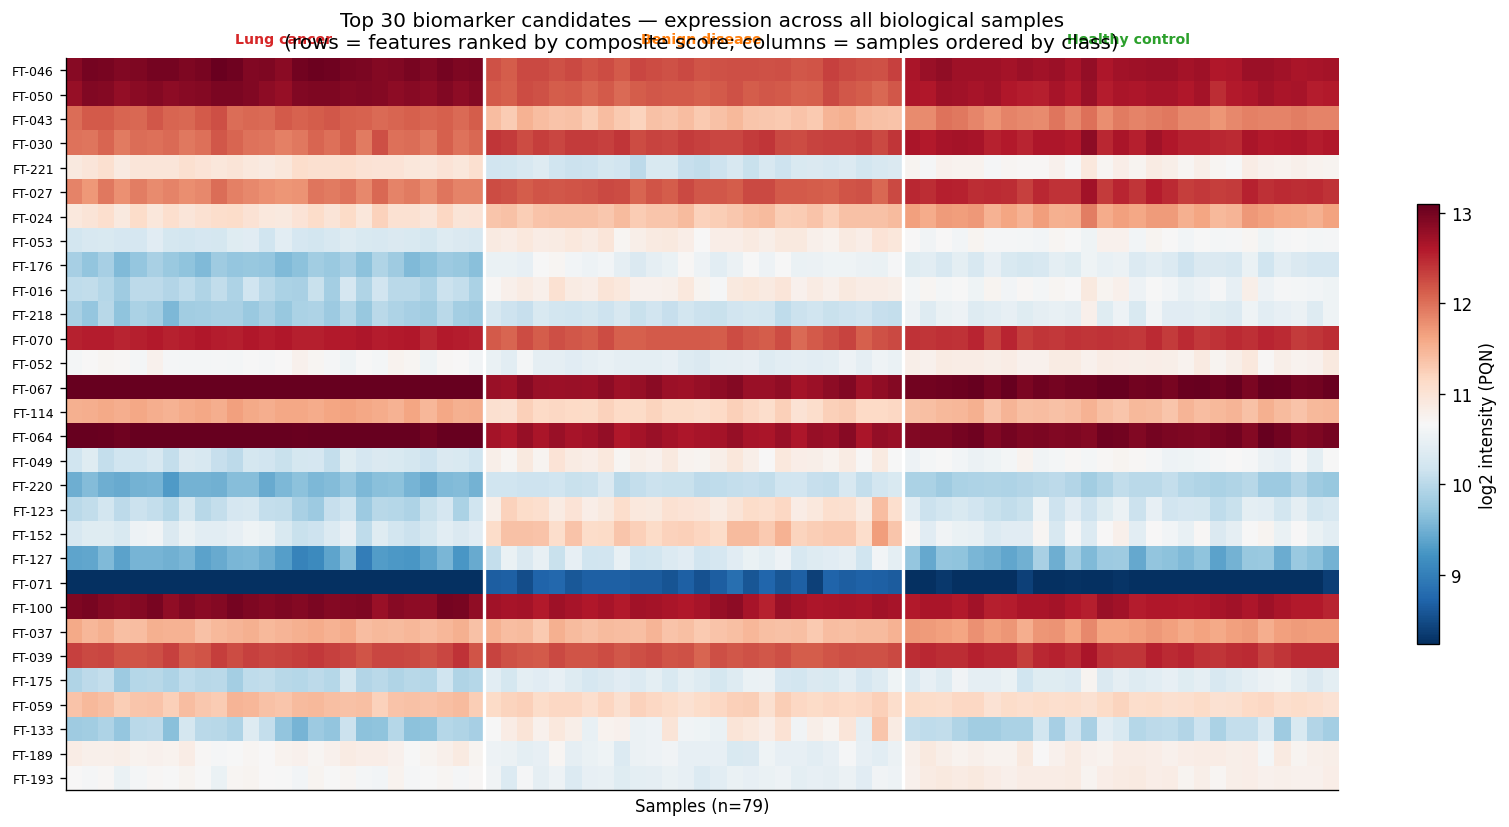

In [12]:
# ── Composite ranking ─────────────────────────────────────────────────────
def minmax(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn) if mx > mn else s * 0.0

score_vip    = minmax(vip_series)
score_q      = minmax(-np.log10(result_df["q_val"].clip(lower=1e-300)))
score_effect = minmax(result_df["effect"])

composite = (score_vip + score_q + score_effect) / 3.0
composite  = composite.sort_values(ascending=False)

top20 = composite.head(20)
print("Top 20 biomarker candidates (composite score):")
rank_df = pd.DataFrame({
    "composite":  top20,
    "VIP":        vip_series[top20.index],
    "q_val":      result_df.loc[top20.index, "q_val"],
    "effect":     result_df.loc[top20.index, "effect"],
    "mz":         feat_meta.loc[top20.index, "mz"],
    "rt":         feat_meta.loc[top20.index, "rt"],
}).round(4)
print(rank_df.to_string())

# ── Annotated heatmap: top 30 features × all bio samples ─────────────────
top30_feats = composite.head(30).index
X_top30     = dm_bio[top30_feats].values  # (n_bio, 30)

# Reorder samples by class
order_idx = []
for cls in BIO_CLASSES:
    order_idx.extend(sm_bio[sm_bio["class"] == cls].index.tolist())
X_hm        = dm_bio.loc[order_idx, top30_feats].values
classes_hm  = sm_bio.loc[order_idx, "class"].values

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(X_hm.T, aspect="auto", cmap="RdBu_r",
               vmin=np.percentile(X_hm, 2), vmax=np.percentile(X_hm, 98))

# Class separator lines
n_french = (sm_bio["class"] == "French").sum()
n_lmu    = (sm_bio["class"] == "LMU").sum()
ax.axvline(n_french - 0.5,           color="white", linewidth=2)
ax.axvline(n_french + n_lmu - 0.5,   color="white", linewidth=2)

# Class labels on top
for cls, start, n in [("French", 0, n_french),
                       ("LMU", n_french, n_lmu),
                       ("Dunn", n_french + n_lmu, (classes_hm == "Dunn").sum())]:
    mid = start + n / 2
    ax.text(mid, -1, CLASS_LABEL[cls], ha="center", va="bottom",
            fontsize=8.5, color=CLASS_COLORS[cls], fontweight="bold")

ax.set_yticks(range(len(top30_feats)))
ax.set_yticklabels(top30_feats, fontsize=7.5)
ax.set_xticks([])
ax.set_xlabel(f"Samples (n={len(order_idx)})")
ax.set_title("Top 30 biomarker candidates — expression across all biological samples\n"
             "(rows = features ranked by composite score; columns = samples ordered by class)")
plt.colorbar(im, ax=ax, shrink=0.6, label="log2 intensity (PQN)")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_top_features_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:** The top-ranked features fall into two biologically distinct groups, each offering a different kind of biomarker evidence:

**Group 1 — Consistent subtle discriminators** (FT-046, FT-050, FT-043; m/z ~1004–1005 Da, RT ~1156 s): These features cluster within 1.5 Da of each other at the same retention time, suggesting they are isotopologues (¹³C isotope peaks) of the same parent glycan. They achieve extremely high η² (0.97–0.98) meaning 97% of their intensity variance is explained by class membership — indicating all three classes have systematically different expression levels. Their composite score is high because they are statistically overwhelming (q ≈ 0) and confirmed by PLS-DA (VIP > 1.3), even though individual fold-changes are modest.

**Group 2 — High-magnitude outliers** (FT-174, FT-172; not in top 20 composite): These show 10–21-fold up-regulation in cancer vs healthy (|log2FC| = 3.4–4.4), the largest absolute changes in the dataset. Their composite score is lower because η² is moderate (0.4–0.5) — the within-class variance is higher, likely because the feature is near the detection limit in healthy/benign samples where missing values were imputed.

Both groups warrant follow-up: Group 1 candidates provide highly reproducible, class-spanning discrimination suitable for ML classification; Group 2 candidates provide the most striking cancer-specific signal suitable for simple threshold-based tests. The heatmap confirms clean expression transitions at class boundaries for both groups.

## 6 · Save Results

| File | Contents |
|------|----------|
| `statistical_results.pkl` | Full univariate result table, composite ranking, VIP scores, volcano hits |

In [13]:
stat_output = {
    "result_df":      result_df,         # omnibus + pairwise stats for all features
    "composite_rank": composite,          # composite score (all features, sorted)
    "top20":          rank_df,            # top 20 annotated
    "vip_scores":     vip_series,         # VIP scores (sorted)
    "volcano_hits":   volcano_hits,       # dict of {(cls_a, cls_b): {up_a, up_b, log2fc}}
    "pls_model":      pls,                # fitted PLS object
    "perm_pval":      perm_pval,          # permutation test p-value
    "q2_real":        q2_real,
    "feature_meta":   feat_meta,
    "sample_meta":    sm_bio,
}
with open(RES_DIR / "statistical_results.pkl", "wb") as f:
    pickle.dump(stat_output, f)

print("Saved: files/results/statistical_results.pkl")
print()
print("=== Summary ===")
print(f"  Significant features (omnibus q < 0.05) : {(result_df['q_val'] < 0.05).sum()}")
for (cls_a, cls_b), label in zip(PAIRS, PAIR_LABELS):
    col = f"q_{cls_a}_vs_{cls_b}"
    n   = (result_df[col] < 0.05).sum()
    up  = len(volcano_hits[(cls_a, cls_b)]["up_in_a"])
    dn  = len(volcano_hits[(cls_a, cls_b)]["up_in_b"])
    print(f"  {label:28s}: {n} sig  ({up} up in {cls_a}, {dn} up in {cls_b})")
print(f"  VIP > 1.0                               : {(vip_series > 1.0).sum()}")
print(f"  Permutation test p-value                : {perm_pval:.3f}")
print(f"  Top candidate                           : {rank_df.index[0]}  "
      f"(m/z={rank_df['mz'].iloc[0]:.2f}, RT={rank_df['rt'].iloc[0]:.0f}s)")

Saved: files/results/statistical_results.pkl

=== Summary ===
  Significant features (omnibus q < 0.05) : 181
  Cancer vs Healthy           : 148 sig  (2 up in French, 0 up in Dunn)
  Cancer vs Benign            : 145 sig  (2 up in French, 2 up in LMU)
  Benign vs Healthy           : 149 sig  (1 up in LMU, 1 up in Dunn)
  VIP > 1.0                               : 91
  Permutation test p-value                : 0.000
  Top candidate                           : FT-046  (m/z=1004.17, RT=1156s)
